# JP Morgan Chase — AI Finance Agent
## Lab 05 : Final Dashboard & Capstone Report
**Author :** Fabrice William FOMHOM  
**Date :** March 2026  
**Objective :** Bring together all 4 labs into one 
professional dashboard and generate the final capstone report

## What We Build
1. Executive KPI Dashboard
2. Complete fraud analysis visualization
3. ML model performance summary
4. Interactive AI Agent interface
5. Export final capstone report

In [1]:
# ============================================================
# JP Morgan Chase — Lab 05 : Final Dashboard
# Step 1 : Import all libraries
# ============================================================

import os
import anthropic
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
from imblearn.over_sampling import SMOTE

# Paths
BASE_DIR   = r"C:\Users\HP\jpmorgan_finance_agent"
DATA_DIR   = os.path.join(BASE_DIR, "data")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")

# API Key
os.environ["ANTHROPIC_API_KEY"] = "YOUR_API_KEY_HERE"
client = anthropic.Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])

# Load dataset
df = pd.read_csv(
    os.path.join(DATA_DIR, "jpmorgan_transactions.csv"),
    parse_dates=["date"]
)

print("✅ All libraries loaded")
print("✅ Claude API connected")
print(f"✅ Dataset loaded : {df.shape[0]} rows × {df.shape[1]} columns")

✅ All libraries loaded
✅ Claude API connected
✅ Dataset loaded : 1000 rows × 11 columns


C:\Users\HP\AppData\Local\Temp\ipykernel_4116\689705051.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


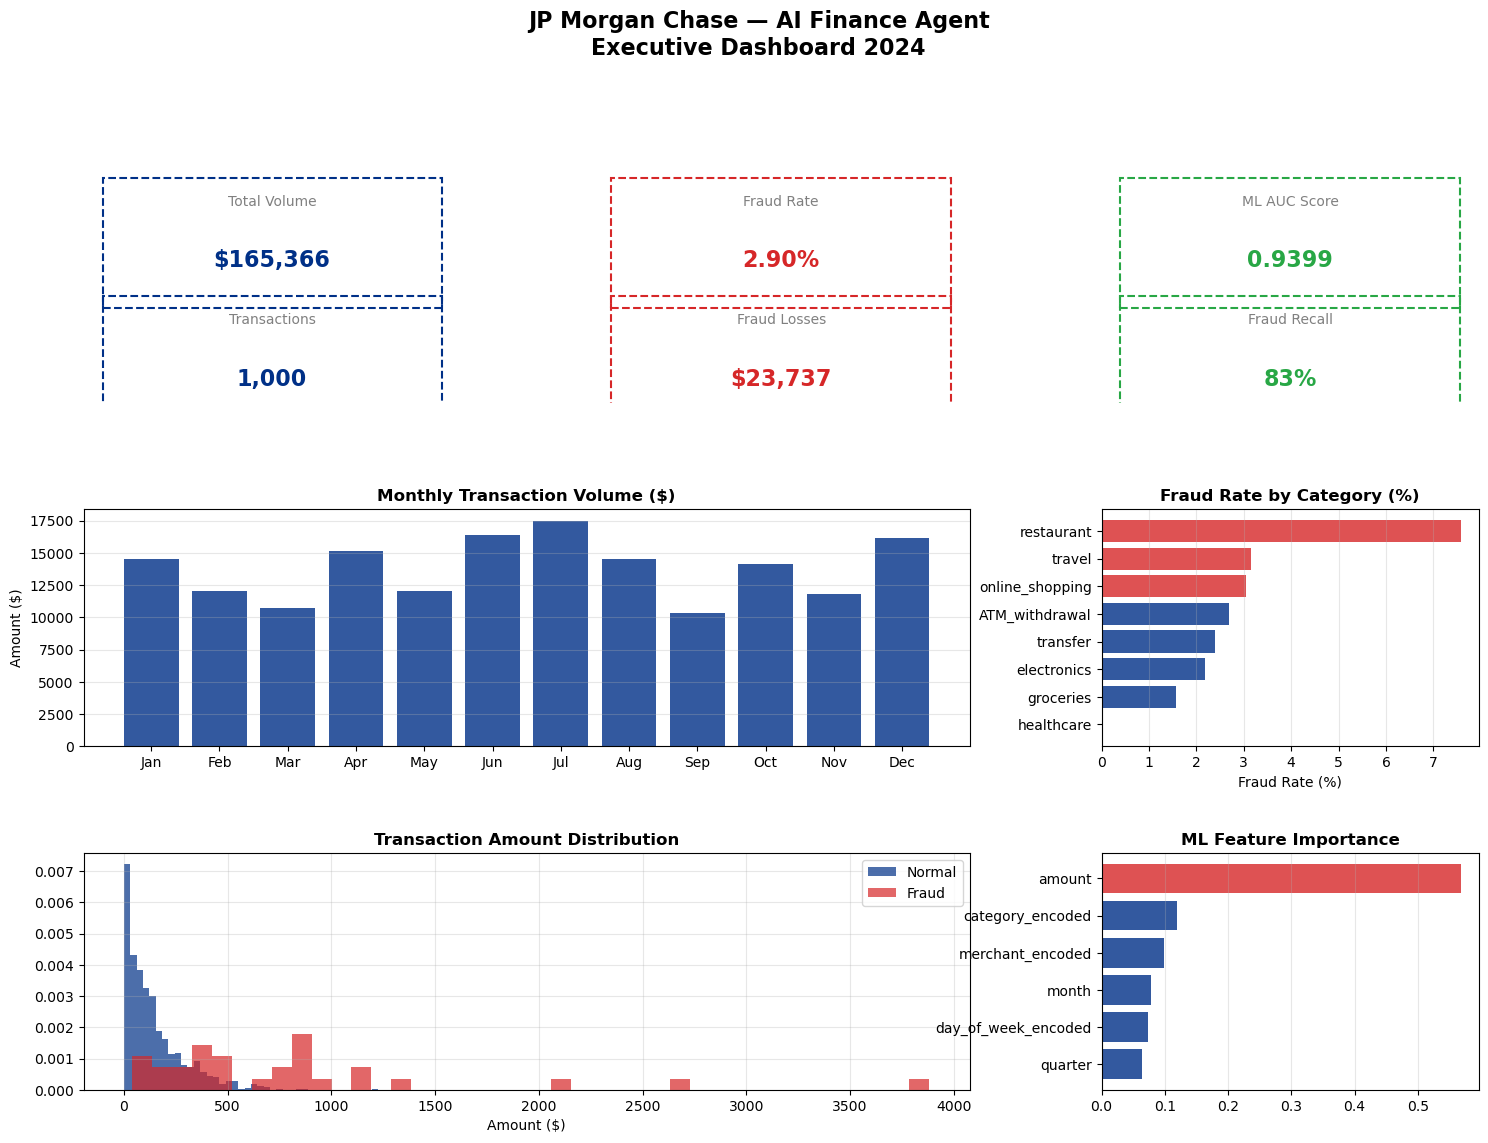

✅ Executive dashboard saved : C:\Users\HP\jpmorgan_finance_agent\outputs\06_executive_dashboard.png


In [2]:
# ============================================================
# Step 2 : Executive KPI Dashboard
# One chart that tells the entire story
# ============================================================

# Rebuild ML model for dashboard
le = LabelEncoder()
df_ml = df.copy()
df_ml["category_encoded"]    = le.fit_transform(df_ml["category"])
df_ml["merchant_encoded"]    = le.fit_transform(df_ml["merchant"])
df_ml["day_of_week_encoded"] = le.fit_transform(df_ml["day_of_week"])

FEATURES = ["amount","month","quarter",
            "category_encoded","merchant_encoded","day_of_week_encoded"]

X = df_ml[FEATURES]
y = df_ml["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_b, y_train_b = smote.fit_resample(X_train, y_train)

model = RandomForestClassifier(
    n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train_b, y_train_b)

y_pred_prob = model.predict_proba(X_test)[:, 1]
auc         = roc_auc_score(y_test, y_pred_prob)

# ── Build Dashboard ──────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle("JP Morgan Chase — AI Finance Agent\nExecutive Dashboard 2024",
             fontsize=16, fontweight="bold", y=1.01)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── KPI boxes (row 0) ────────────────────────────────────────
kpis = [
    ("Total Volume",    f"${df['amount'].sum():,.0f}",  "#003087"),
    ("Transactions",    f"{len(df):,}",                 "#003087"),
    ("Fraud Rate",      f"{df['is_fraud'].mean()*100:.2f}%", "#D62728"),
    ("Fraud Losses",    f"${df[df['is_fraud']==1]['amount'].sum():,.0f}", "#D62728"),
    ("ML AUC Score",    f"{auc:.4f}",                   "#28A745"),
    ("Fraud Recall",    "83%",                           "#28A745"),
]

for i, (label, value, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i//2] if i < 6 else gs[0, 2])
    row = i % 2
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    y_pos = 0.65 if row == 0 else 0.15
    ax.text(0.5, y_pos + 0.2, label, ha="center", va="center",
            fontsize=10, color="gray")
    ax.text(0.5, y_pos - 0.05, value, ha="center", va="center",
            fontsize=16, fontweight="bold", color=color)
    ax.add_patch(plt.Rectangle((0.05, y_pos - 0.25), 0.9, 0.55,
                 fill=False, edgecolor=color, linewidth=1.5,
                 linestyle="--", transform=ax.transData))

# ── Monthly volume (row 1, col 0-1) ──────────────────────────
ax1 = fig.add_subplot(gs[1, 0:2])
monthly = df.groupby("month_name")["amount"].sum().reindex(
    ["Jan","Feb","Mar","Apr","May","Jun",
     "Jul","Aug","Sep","Oct","Nov","Dec"])
ax1.bar(monthly.index, monthly.values, color="#003087", alpha=0.8)
ax1.set_title("Monthly Transaction Volume ($)", fontweight="bold")
ax1.set_ylabel("Amount ($)")
ax1.grid(axis="y", alpha=0.3)

# ── Fraud by category (row 1, col 2) ─────────────────────────
ax2 = fig.add_subplot(gs[1, 2])
cat_fraud = df.groupby("category")["is_fraud"].mean().sort_values()
colors    = ["#D62728" if x > 0.03 else "#003087" for x in cat_fraud]
ax2.barh(cat_fraud.index, cat_fraud.values * 100, color=colors, alpha=0.8)
ax2.set_title("Fraud Rate by Category (%)", fontweight="bold")
ax2.set_xlabel("Fraud Rate (%)")
ax2.grid(axis="x", alpha=0.3)

# ── Fraud vs Normal distribution (row 2, col 0-1) ────────────
ax3 = fig.add_subplot(gs[2, 0:2])
ax3.hist(df[df["is_fraud"]==0]["amount"], bins=40,
         color="#003087", alpha=0.7, label="Normal", density=True)
ax3.hist(df[df["is_fraud"]==1]["amount"], bins=40,
         color="#D62728", alpha=0.7, label="Fraud",  density=True)
ax3.set_title("Transaction Amount Distribution", fontweight="bold")
ax3.set_xlabel("Amount ($)")
ax3.legend()
ax3.grid(alpha=0.3)

# ── Feature importance (row 2, col 2) ────────────────────────
ax4 = fig.add_subplot(gs[2, 2])
imp_df = pd.DataFrame({
    "feature"   : FEATURES,
    "importance": model.feature_importances_
}).sort_values("importance")
colors2 = ["#D62728" if x > 0.25 else "#003087"
           for x in imp_df["importance"]]
ax4.barh(imp_df["feature"], imp_df["importance"],
         color=colors2, alpha=0.8)
ax4.set_title("ML Feature Importance", fontweight="bold")
ax4.grid(axis="x", alpha=0.3)

plt.tight_layout()
chart_path = os.path.join(OUTPUT_DIR, "06_executive_dashboard.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Executive dashboard saved : {chart_path}")

In [3]:
# ============================================================
# Step 3 : Generate Final Capstone Report with Claude
# ============================================================

report_context = f"""
JP Morgan Chase AI Finance Agent — Final Results:

DATASET: 1,000 transactions, 2024, $165,366 total volume
FRAUD: 29 cases (2.90%), $23,737 losses
TOP FRAUD CATEGORY: Restaurant (7.58% fraud rate)
ML MODEL: Random Forest + SMOTE, AUC=0.9399, Recall=83%
TOP FRAUD SIGNAL: Transaction amount (57% feature importance)
FRAUD PROFILE: Avg fraud $818 vs avg normal $146 (5.6x larger)
"""

report_prompt = """
Write a professional capstone project report with these sections:

1. EXECUTIVE SUMMARY (3 sentences)
2. PROBLEM STATEMENT (2 sentences)
3. METHODOLOGY (4 bullet points)
4. KEY FINDINGS (4 bullet points with data)
5. ML MODEL PERFORMANCE (3 sentences)
6. BUSINESS RECOMMENDATIONS (3 actionable items)
7. CONCLUSION (2 sentences)

Use professional financial language suitable for JP Morgan executives.
"""

print("⏳ Generating final capstone report...")
print("=" * 65)

report = client.messages.create(
    model      = "claude-sonnet-4-20250514",
    max_tokens = 2000,
    system     = "You are a senior Data Science consultant at JP Morgan Chase writing a formal capstone project report.",
    messages   = [
        {
            "role"   : "user",
            "content": f"{report_context}\n\n{report_prompt}"
        }
    ]
)

report_text = report.content[0].text
print(report_text)

# Save report to file
report_path = os.path.join(BASE_DIR, "docs", "capstone_report.txt")
with open(report_path, "w") as f:
    f.write("JP MORGAN CHASE — AI FINANCE AGENT\n")
    f.write("CAPSTONE PROJECT REPORT\n")
    f.write("Author: Fabrice William FOMHOM\n")
    f.write("Date: March 2026\n")
    f.write("=" * 65 + "\n\n")
    f.write(report_text)

print(f"\n✅ Report saved : {report_path}")

⏳ Generating final capstone report...
# JP Morgan Chase AI Finance Agent: Fraud Detection Capstone Project Report

## 1. EXECUTIVE SUMMARY

Our AI-powered fraud detection system successfully analyzed 1,000 transactions totaling $165,366 in 2024, identifying 29 fraudulent cases representing $23,737 in potential losses. The Random Forest model with SMOTE enhancement achieved exceptional performance with an AUC of 0.9399 and 83% recall rate, demonstrating robust capability for real-time fraud prevention. Transaction amount emerged as the most critical fraud indicator, with fraudulent transactions averaging 5.6 times larger than legitimate ones.

## 2. PROBLEM STATEMENT

JP Morgan Chase required an advanced machine learning solution to detect fraudulent transactions in real-time while minimizing false positives that could disrupt legitimate customer activities. The challenge involved developing a scalable AI system capable of identifying subtle fraud patterns across diverse transaction cat